# Analysing Sentiment, Emotion, and Polarisation in Reddit Discussions on the Palestine-Israel Conflict Using Machine Learning

## Member 1: Data & Traditional ML Lead

This member focuses on dataset preparation, text preprocessing, TF-IDF feature extraction, traditional machine learning model training, and model evaluation.


## 1. Import Libraries

In [1]:
import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt
import seaborn as sns

import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from nltk.tokenize import word_tokenize

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer

from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import LinearSVC

from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

import warnings
warnings.filterwarnings('ignore')

In [2]:
nltk.download("punkt")
nltk.download("punkt_tab")
nltk.download("stopwords")
nltk.download("wordnet")
nltk.download("omw-1.4")
nltk.download("vader_lexicon")

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\isha0\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\isha0\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\isha0\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\isha0\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to
[nltk_data]     C:\Users\isha0\AppData\Roaming\nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!
[nltk_data] Downloading package vader_lexicon to
[nltk_data]     C:\Users\isha0\AppData\Roaming\nltk_data...
[nltk_data]   Package vader_lexicon is already up-to-date!


True

## 2. Load Dataset

In [3]:
df = pd.read_csv("reddit_dataset.csv")

df.head()

,comment_id,score,self_text,subreddit,created_time,post_id,author_name,controversiality,ups,downs,...,user_link_karma,user_comment_karma,user_total_karma,post_score,post_self_text,post_title,post_upvote_ratio,post_thumbs_ups,post_total_awards_received,post_created_time
0,onkan89,1,That's just Palestine's history lol,IsraelPalestine,2026-05-24 07:15:09,1tlvu9b,Late_Ad2203,0,1,0,...,206.0,19329.0,19535.0,78,"From what I can tell, the incident took placed...",Gaza floatila activists beaten up and detained...,0.85,78,0,2026-05-23 23:42:20
1,onkalu2,1,Just going to leave this here. Israel are defe...,IsraelPalestine,2026-05-24 07:14:48,1tlvu9b,Late_Ad2203,0,1,0,...,206.0,19329.0,19535.0,78,"From what I can tell, the incident took placed...",Gaza floatila activists beaten up and detained...,0.85,78,0,2026-05-23 23:42:20
2,onkakbn,1,What kind of physical evidence would it leave ...,IsraelPalestine,2026-05-24 07:14:26,1tkmfii,OneReportersOpinion,0,1,0,...,46382.0,283342.0,329724.0,18,Re: the Kristoff piece on Israeli prison rape....,More thoughts on the Kristof opinion editorial,0.74,18,0,2026-05-22 15:31:32
3,onka939,1,I mean... you mention that this documentation ...,IsraelPalestine,2026-05-24 07:11:45,1tlx2k8,warsage,0,1,0,...,2105.0,86167.0,88272.0,0,The goal of this post is to document sexual as...,An investigation into sexual assault in the Is...,0.50,0,0,2026-05-24 00:37:21
4,onka51q,1,An airport is not the best place to cause trou...,worldnews,2026-05-24 07:10:46,1tllkrd,Efficient-Wolf7068,0,1,0,...,1.0,3103.0,3104.0,2540,NaN,Clashes in Spain: Gaza flotilla activists beat...,0.87,2540,0,2026-05-23 16:47:24


## 3. Dataset Overview

In [4]:
df.shape

(354299, 24)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 354299 entries, 0 to 354298
Data columns (total 24 columns):
 #   Column                      Non-Null Count   Dtype  
---  ------                      --------------   -----  
 0   comment_id                  354299 non-null  object 
 1   score                       354299 non-null  int64  
 2   self_text                   354298 non-null  object 
 3   subreddit                   354299 non-null  object 
 4   created_time                354299 non-null  object 
 5   post_id                     354299 non-null  object 
 6   author_name                 354299 non-null  object 
 7   controversiality            354299 non-null  int64  
 8   ups                         354299 non-null  int64  
 9   downs                       354299 non-null  int64  
 10  user_is_verified            354299 non-null  bool   
 11  user_account_created_time   348951 non-null  object 
 12  user_awardee_karma          354247 non-null  float64
 13  user_awarder_k

In [6]:
df.columns

Index(['comment_id', 'score', 'self_text', 'subreddit', 'created_time',
       'post_id', 'author_name', 'controversiality', 'ups', 'downs',
       'user_is_verified', 'user_account_created_time', 'user_awardee_karma',
       'user_awarder_karma', 'user_link_karma', 'user_comment_karma',
       'user_total_karma', 'post_score', 'post_self_text', 'post_title',
       'post_upvote_ratio', 'post_thumbs_ups', 'post_total_awards_received',
       'post_created_time'],
      dtype='object')

In [7]:
df.isnull().sum()

comment_id                         0
score                              0
self_text                          1
subreddit                          0
created_time                       0
post_id                            0
author_name                        0
controversiality                   0
ups                                0
downs                              0
user_is_verified                   0
user_account_created_time       5348
user_awardee_karma                52
user_awarder_karma                52
user_link_karma                   52
user_comment_karma                52
user_total_karma                  52
post_score                         0
post_self_text                192422
post_title                         0
post_upvote_ratio                  0
post_thumbs_ups                    0
post_total_awards_received         0
post_created_time                  0
dtype: int64

In [8]:
df.duplicated().sum()

np.int64(0)

## 4. Exploratory Data Analysis (EDA)

#### EDA 1: Dataset Size

In [9]:
print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])

Number of rows: 354299
Number of columns: 24


#### EDA 2: Missing Values

In [10]:
missing_values = df.isnull().sum().sort_values(ascending=False)
missing_values[missing_values > 0]

post_self_text               192422
user_account_created_time      5348
user_awardee_karma               52
user_awarder_karma               52
user_total_karma                 52
user_comment_karma               52
user_link_karma                  52
self_text                         1
dtype: int64

#### EDA 3: Duplicate Rows

In [11]:
print("Total duplicate rows:", df.duplicated().sum())

Total duplicate rows: 0


#### EDA 4: Subreddit Distribution

In [12]:
df["subreddit"].value_counts().head(10)

subreddit
IsraelPalestine       106696
worldnews             103211
PublicFreakout         55561
Palestine              33303
CombatFootage          21396
AskMiddleEast          12712
NonCredibleDefense      7475
CrazyFuckingVideos      5902
worldnewsvideo          4659
NoahGetTheBoat          1556
Name: count, dtype: int64

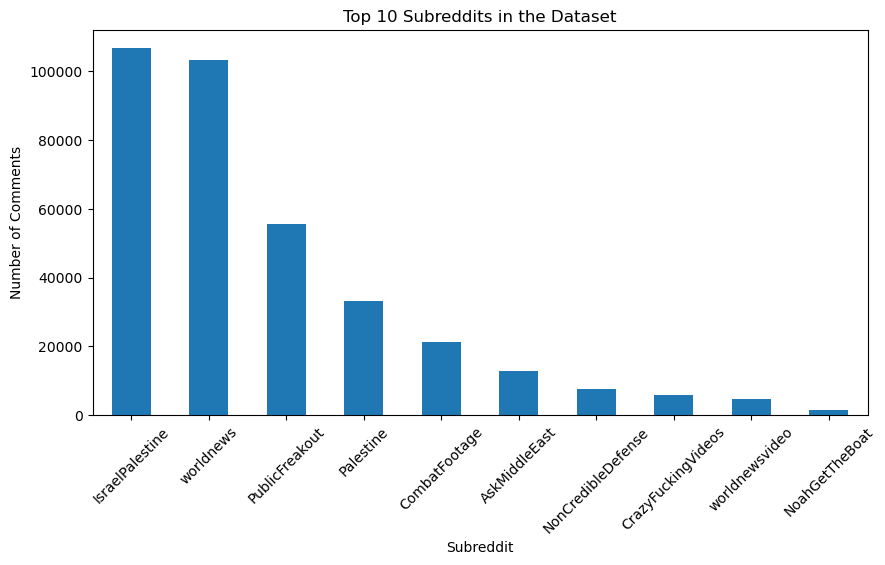

In [13]:
plt.figure(figsize=(10,5))
df["subreddit"].value_counts().head(10).plot(kind="bar")
plt.title("Top 10 Subreddits in the Dataset")
plt.xlabel("Subreddit")
plt.ylabel("Number of Comments")
plt.xticks(rotation=45)
plt.show()

#### EDA 5: Text Length Analysis

In [14]:
df["text_length"] = df["self_text"].fillna("").astype(str).apply(len)
df["word_count"] = df["self_text"].fillna("").astype(str).apply(lambda x: len(x.split()))

In [15]:
df[["text_length", "word_count"]].describe()

,text_length,word_count
count,354299.000000,354299.000000
mean,234.686790,39.126969
std,392.153017,62.886891
min,0.000000,0.000000
25%,54.000000,9.000000
50%,115.000000,20.000000
75%,254.000000,43.000000
max,9929.000000,1653.000000


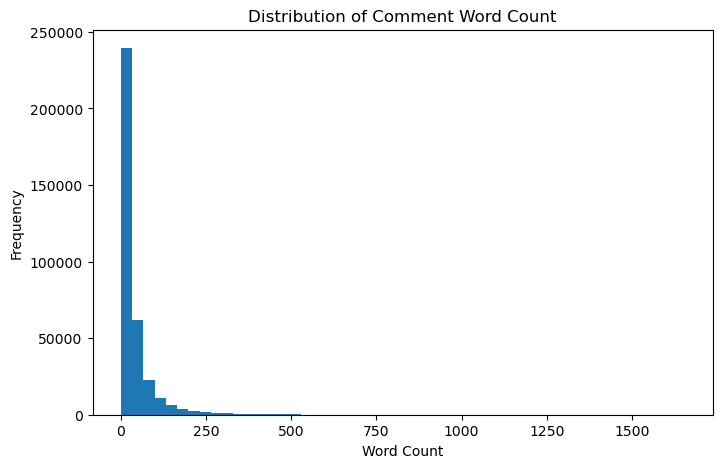

In [16]:
plt.figure(figsize=(8,5))
plt.hist(df["word_count"], bins=50)
plt.title("Distribution of Comment Word Count")
plt.xlabel("Word Count")
plt.ylabel("Frequency")
plt.show()

#### EDA 6: Engagement Features

In [17]:
df[["score", "ups", "downs", "controversiality"]].describe()

,score,ups,downs,controversiality
count,354299.000000,354299.000000,354299.0,354299.000000
mean,29.745780,29.745780,0.0,0.076148
std,247.986231,247.986231,0.0,0.265234
min,-549.000000,-549.000000,0.0,0.000000
25%,1.000000,1.000000,0.0,0.000000
50%,3.000000,3.000000,0.0,0.000000
75%,11.000000,11.000000,0.0,0.000000
max,31613.000000,31613.000000,0.0,1.000000


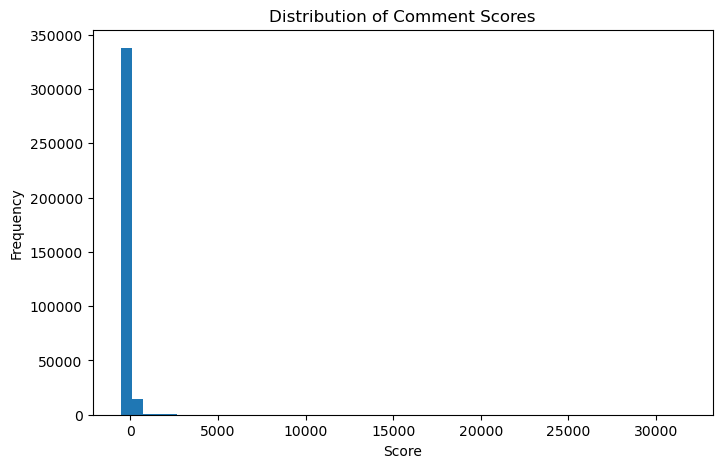

In [18]:
plt.figure(figsize=(8,5))
plt.hist(df["score"], bins=50)
plt.title("Distribution of Comment Scores")
plt.xlabel("Score")
plt.ylabel("Frequency")
plt.show()

In [19]:
df["controversiality"].value_counts()

controversiality
0    327320
1     26979
Name: count, dtype: int64

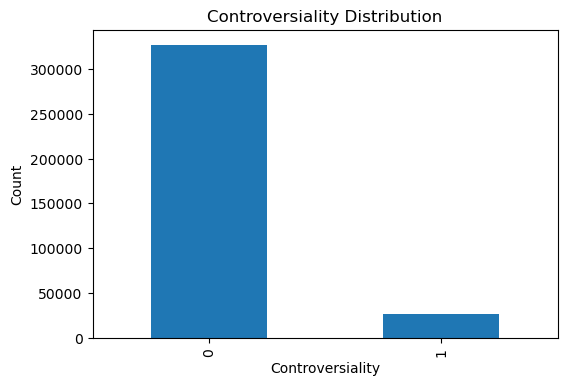

In [20]:
plt.figure(figsize=(6,4))
df["controversiality"].value_counts().plot(kind="bar")
plt.title("Controversiality Distribution")
plt.xlabel("Controversiality")
plt.ylabel("Count")
plt.show()

#### EDA 7: Time-based Analysis

In [21]:
df["created_time"] = pd.to_datetime(df["created_time"], errors="coerce")
df["date"] = df["created_time"].dt.date

In [22]:
comments_by_date = df.groupby("date").size()

comments_by_date.head()

date
2026-01-01    1255
2026-01-02    1511
2026-01-03    1577
2026-01-04    1816
2026-01-05    1937
dtype: int64

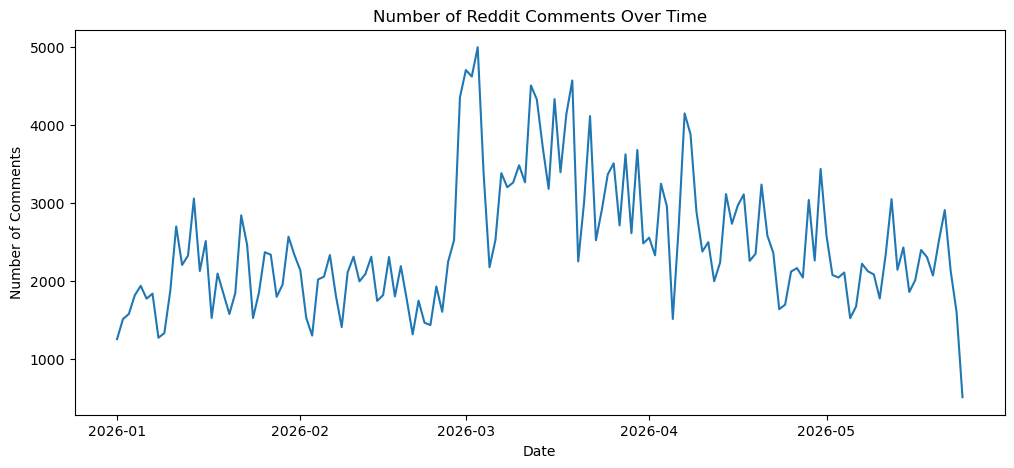

In [23]:
plt.figure(figsize=(12,5))
comments_by_date.plot()
plt.title("Number of Reddit Comments Over Time")
plt.xlabel("Date")
plt.ylabel("Number of Comments")
plt.show()

## 5. Select Text Column

In [24]:
df.columns

Index(['comment_id', 'score', 'self_text', 'subreddit', 'created_time',
       'post_id', 'author_name', 'controversiality', 'ups', 'downs',
       'user_is_verified', 'user_account_created_time', 'user_awardee_karma',
       'user_awarder_karma', 'user_link_karma', 'user_comment_karma',
       'user_total_karma', 'post_score', 'post_self_text', 'post_title',
       'post_upvote_ratio', 'post_thumbs_ups', 'post_total_awards_received',
       'post_created_time', 'text_length', 'word_count', 'date'],
      dtype='object')

In [25]:
df["combined_text"] = (
    df["post_title"].fillna("") + " " +
    df["self_text"].fillna("")
)

text_column = "combined_text"

df[[text_column]].head()

,combined_text
0,Gaza floatila activists beaten up and detained...
1,Gaza floatila activists beaten up and detained...
2,More thoughts on the Kristof opinion editorial...
3,An investigation into sexual assault in the Is...
4,Clashes in Spain: Gaza flotilla activists beat...


In [26]:
df[text_column].isnull().sum()

np.int64(0)

In [27]:
df[text_column].head(10)

0    Gaza floatila activists beaten up and detained...
1    Gaza floatila activists beaten up and detained...
2    More thoughts on the Kristof opinion editorial...
3    An investigation into sexual assault in the Is...
4    Clashes in Spain: Gaza flotilla activists beat...
5    TRT World - France bans Israel's Ben-Gvir over...
6    Israel intercepts the Gaza flotilla and deport...
7    I'm the only Pro-Israel student in my universi...
8    Israel intercepts the Gaza flotilla and deport...
9    I'm the only Pro-Israel student in my universi...
Name: combined_text, dtype: object

## 6. Remove Missing and Duplicate Text

In [28]:
df = df[df[text_column].astype(str).str.strip() != ""]

In [29]:
df = df.drop_duplicates(subset=[text_column])

In [30]:
df.shape

(353472, 28)

## 7. Data Cleaning

In [31]:
def clean_text(text):
    text = str(text).lower()
    text = re.sub(r"http\S+|www\S+", "", text)
    text = re.sub(r"@\w+", "", text)
    text = re.sub(r"[^a-zA-Z\s]", "", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text

In [32]:
df["clean_text"] = df[text_column].apply(clean_text)

df[[text_column, "clean_text"]].head()

,combined_text,clean_text
0,Gaza floatila activists beaten up and detained...,gaza floatila activists beaten up and detained...
1,Gaza floatila activists beaten up and detained...,gaza floatila activists beaten up and detained...
2,More thoughts on the Kristof opinion editorial...,more thoughts on the kristof opinion editorial...
3,An investigation into sexual assault in the Is...,an investigation into sexual assault in the is...
4,Clashes in Spain: Gaza flotilla activists beat...,clashes in spain gaza flotilla activists beate...


## 8. Text Preprocessing

In [33]:
stop_words = set(stopwords.words("english"))
lemmatizer = WordNetLemmatizer()

In [34]:
def preprocess_text(text):
    tokens = word_tokenize(text)
    tokens = [word for word in tokens if word not in stop_words]
    tokens = [lemmatizer.lemmatize(word) for word in tokens]
    return " ".join(tokens)

In [35]:
df["processed_text"] = df["clean_text"].apply(preprocess_text)

df[["clean_text", "processed_text"]].head()

,clean_text,processed_text
0,gaza floatila activists beaten up and detained...,gaza floatila activist beaten detained spanish...
1,gaza floatila activists beaten up and detained...,gaza floatila activist beaten detained spanish...
2,more thoughts on the kristof opinion editorial...,thought kristof opinion editorial kind physica...
3,an investigation into sexual assault in the is...,investigation sexual assault israelpalestine c...
4,clashes in spain gaza flotilla activists beate...,clash spain gaza flotilla activist beaten poli...


## 9. Sentiment Label Preparation

In [36]:
from nltk.sentiment import SentimentIntensityAnalyzer

sia = SentimentIntensityAnalyzer()

In [37]:
df["compound"] = df["processed_text"].apply(
    lambda x: sia.polarity_scores(x)["compound"]
)

In [38]:
def label_sentiment(score):
    if score >= 0.05:
        return "positive"
    elif score <= -0.05:
        return "negative"
    else:
        return "neutral"

In [39]:
df["sentiment"] = df["compound"].apply(label_sentiment)

target_column = "sentiment"

df["sentiment"].value_counts()

sentiment
negative    212125
positive    113230
neutral      28117
Name: count, dtype: int64

## 10. Check Class Distribution

In [40]:
df[target_column].value_counts()

sentiment
negative    212125
positive    113230
neutral      28117
Name: count, dtype: int64

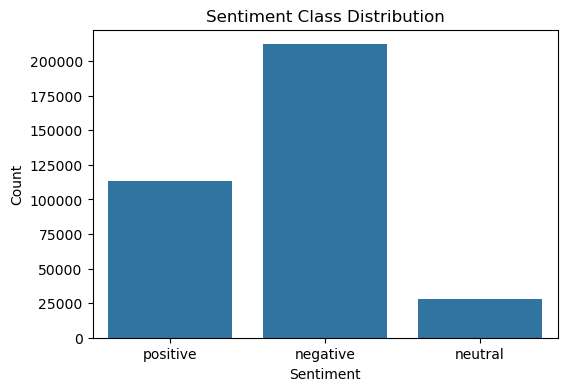

In [41]:
plt.figure(figsize=(6,4))
sns.countplot(data=df, x=target_column)
plt.title("Sentiment Class Distribution")
plt.xlabel("Sentiment")
plt.ylabel("Count")
plt.show()

## 11. Train-Test Split

In [42]:
X_text = df["processed_text"]
y = df[target_column]

In [43]:
X_train_text, X_test_text, y_train, y_test = train_test_split(
    X_text,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [44]:
print("Training size:", X_train_text.shape)
print("Testing size:", X_test_text.shape)

Training size: (282777,)
Testing size: (70695,)


## 12. TF-IDF Feature Extraction

In [45]:
tfidf = TfidfVectorizer(
    max_features=5000,
    ngram_range=(1, 2)
)

In [46]:
X_train = tfidf.fit_transform(X_train_text)
X_test = tfidf.transform(X_test_text)

In [47]:
print("TF-IDF training shape:", X_train.shape)
print("TF-IDF testing shape:", X_test.shape)

TF-IDF training shape: (282777, 5000)
TF-IDF testing shape: (70695, 5000)


## 13. Logistic Regression Model

Logistic Regression is trained as one of the traditional machine learning models for sentiment classification.

In [48]:
lr_model = LogisticRegression(max_iter=1000)
lr_model.fit(X_train, y_train)

lr_pred = lr_model.predict(X_test)

In [49]:
print("Logistic Regression Accuracy:", accuracy_score(y_test, lr_pred))
print(classification_report(y_test, lr_pred))

Logistic Regression Accuracy: 0.8719145625574651
              precision    recall  f1-score   support

    negative       0.89      0.93      0.91     42425
     neutral       0.83      0.62      0.71      5624
    positive       0.85      0.83      0.84     22646

    accuracy                           0.87     70695
   macro avg       0.85      0.79      0.82     70695
weighted avg       0.87      0.87      0.87     70695



## 14. Naive Bayes Model

Naive Bayes is trained as a baseline model because it is commonly used for text classification tasks.

In [50]:
nb_model = MultinomialNB()
nb_model.fit(X_train, y_train)

nb_pred = nb_model.predict(X_test)

In [51]:
print("Naive Bayes Accuracy:", accuracy_score(y_test, nb_pred))
print(classification_report(y_test, nb_pred))

Naive Bayes Accuracy: 0.7310276540066483
              precision    recall  f1-score   support

    negative       0.73      0.92      0.82     42425
     neutral       0.50      0.15      0.23      5624
    positive       0.75      0.52      0.61     22646

    accuracy                           0.73     70695
   macro avg       0.66      0.53      0.55     70695
weighted avg       0.72      0.73      0.70     70695



## 15. Support Vector Machine Model

Support Vector Machine is trained using LinearSVC because it works well with high-dimensional TF-IDF text features.

In [52]:
svm_model = LinearSVC()
svm_model.fit(X_train, y_train)

svm_pred = svm_model.predict(X_test)

In [53]:
print("SVM Accuracy:", accuracy_score(y_test, svm_pred))
print(classification_report(y_test, svm_pred))

SVM Accuracy: 0.8690713628969517
              precision    recall  f1-score   support

    negative       0.89      0.93      0.91     42425
     neutral       0.83      0.59      0.69      5624
    positive       0.84      0.83      0.84     22646

    accuracy                           0.87     70695
   macro avg       0.85      0.78      0.81     70695
weighted avg       0.87      0.87      0.87     70695



## 16. Confusion Matrix

In [54]:
models = {
    "Logistic Regression": lr_pred,
    "Naive Bayes": nb_pred,
    "SVM": svm_pred
}

labels = sorted(y.unique())

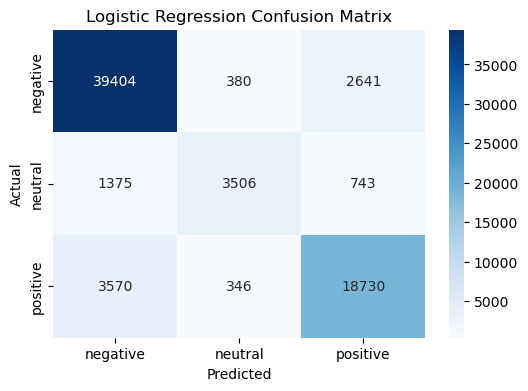

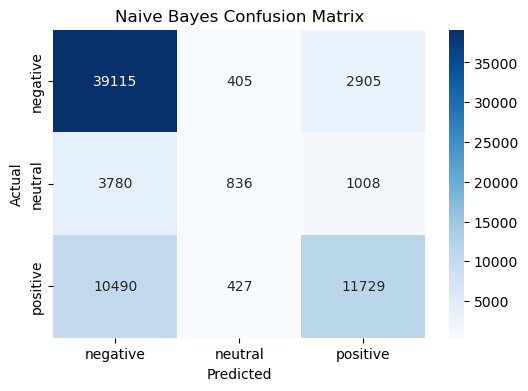

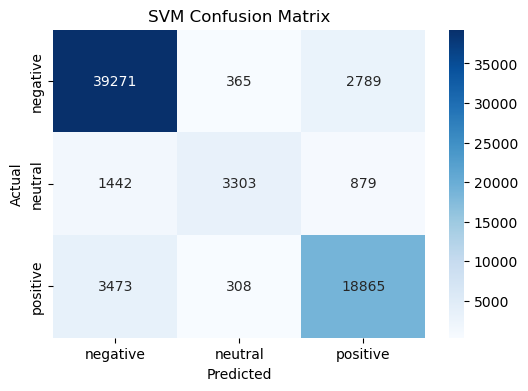

In [55]:
for name, pred in models.items():
    cm = confusion_matrix(y_test, pred, labels=labels)
    
    plt.figure(figsize=(6, 4))
    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        xticklabels=labels,
        yticklabels=labels
    )
    plt.title(f"{name} Confusion Matrix")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()

## 17. Model Comparison

In [56]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

results = pd.DataFrame({
    "Model": ["Logistic Regression", "Naive Bayes", "SVM"],
    
    "Accuracy": [
        accuracy_score(y_test, lr_pred),
        accuracy_score(y_test, nb_pred),
        accuracy_score(y_test, svm_pred)
    ],
    
    "Precision (Macro)": [
        precision_score(y_test, lr_pred, average="macro"),
        precision_score(y_test, nb_pred, average="macro"),
        precision_score(y_test, svm_pred, average="macro")
    ],
    
    "Recall (Macro)": [
        recall_score(y_test, lr_pred, average="macro"),
        recall_score(y_test, nb_pred, average="macro"),
        recall_score(y_test, svm_pred, average="macro")
    ],
    
    "F1-score (Macro)": [
        f1_score(y_test, lr_pred, average="macro"),
        f1_score(y_test, nb_pred, average="macro"),
        f1_score(y_test, svm_pred, average="macro")
    ],
    
    "F1-score (Weighted)": [
        f1_score(y_test, lr_pred, average="weighted"),
        f1_score(y_test, nb_pred, average="weighted"),
        f1_score(y_test, svm_pred, average="weighted")
    ]
})

results

,Model,Accuracy,Precision (Macro),Recall (Macro),F1-score (Macro),F1-score (Weighted)
0,Logistic Regression,0.871915,0.854641,0.793090,0.818850,0.869709
1,Naive Bayes,0.731028,0.661245,0.529519,0.552826,0.704500
2,SVM,0.869071,0.852239,0.782000,0.810028,0.866465


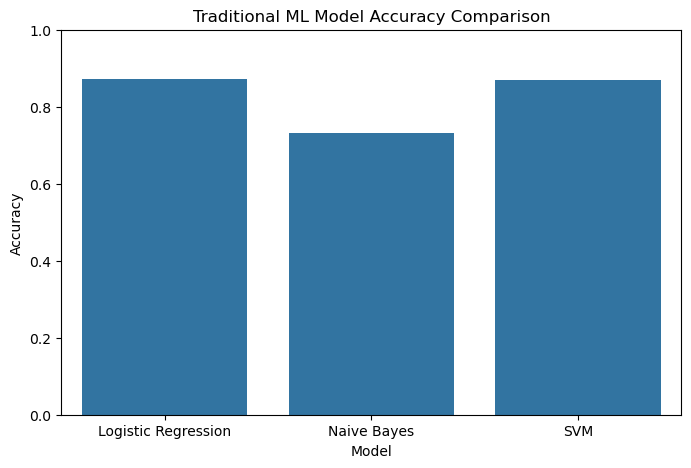

In [57]:
plt.figure(figsize=(8, 5))
sns.barplot(data=results, x="Model", y="Accuracy")
plt.title("Traditional ML Model Accuracy Comparison")
plt.ylim(0, 1)
plt.xlabel("Model")
plt.ylabel("Accuracy")
plt.show()

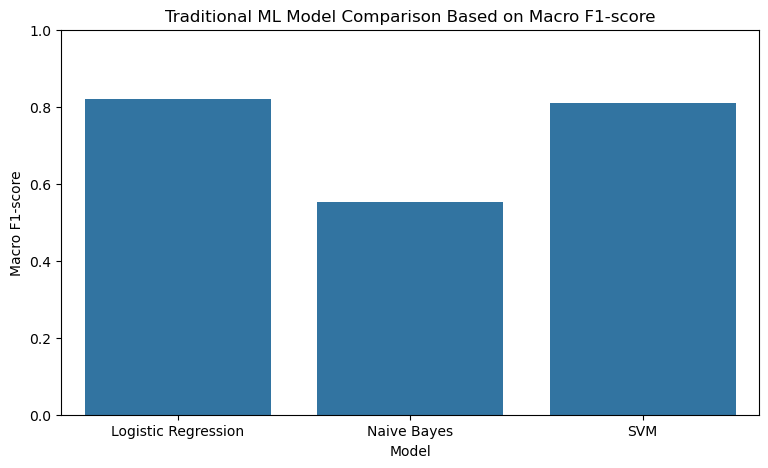

In [58]:
plt.figure(figsize=(9, 5))
sns.barplot(data=results, x="Model", y="F1-score (Macro)")
plt.title("Traditional ML Model Comparison Based on Macro F1-score")
plt.ylim(0, 1)
plt.xlabel("Model")
plt.ylabel("Macro F1-score")
plt.show()

## 18. Save Output

The cleaned dataset and model comparison results are saved for report writing, presentation, and future integration with other group members.

In [59]:
df.to_csv("cleaned_reddit_sentiment_dataset.csv", index=False)
results.to_csv("traditional_ml_model_results.csv", index=False)

Since the dataset did not contain predefined sentiment labels, VADER was used to generate initial sentiment classes based on compound sentiment scores. These generated labels were then used as the target variable for training traditional machine learning models.

## 19. Deep Learning & Emotion Analysis

### 19.1 LSTM Model

In [66]:
pip install tensorflow

   ---------------------------------------- 0.0/351.2 MB ? eta -:--:--
   ---------------------------------------- 4.2/351.2 MB 22.4 MB/s eta 0:00:16
   - -------------------------------------- 9.2/351.2 MB 22.6 MB/s eta 0:00:16
   - -------------------------------------- 14.4/351.2 MB 23.7 MB/s eta 0:00:15
   -- ------------------------------------- 19.4/351.2 MB 23.8 MB/s eta 0:00:14
   -- ------------------------------------- 24.6/351.2 MB 24.1 MB/s eta 0:00:14
   --- ------------------------------------ 30.1/351.2 MB 24.5 MB/s eta 0:00:14
   ---- ----------------------------------- 35.7/351.2 MB 24.6 MB/s eta 0:00:13
   ---- ----------------------------------- 41.7/351.2 MB 25.1 MB/s eta 0:00:13
   ----- ---------------------------------- 46.9/351.2 MB 25.1 MB/s eta 0:00:13
   ----- ---------------------------------- 52.4/351.2 MB 25.2 MB/s eta 0:00:12
   ------ --------------------------------- 57.1/351.2 MB 25.0 MB/s eta 0:00:12
   ------- -------------------------------- 61.9/35

ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
streamlit 1.51.0 requires protobuf<7,>=3.20, but you have protobuf 7.35.0 which is incompatible.


In [67]:
from sklearn.preprocessing import LabelEncoder

encoder = LabelEncoder()

df['label'] = encoder.fit_transform(
    df['sentiment']
)

In [68]:
X_train, X_test, y_train, y_test = train_test_split (
    df['clean_text'],
    df['label'],
    test_size = 0.2,
    random_state =42
)

In [69]:
import tensorflow as tf

from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

MAX_WORDS = 10000
MAX_LEN = 150

tokenizer = Tokenizer(
    num_words=MAX_WORDS
)

tokenizer.fit_on_texts(X_train)

X_train_seq = tokenizer.texts_to_sequences(
    X_train
)

X_test_seq = tokenizer.texts_to_sequences(
    X_test
)

X_train_pad = pad_sequences(
    X_train_seq,
    maxlen=MAX_LEN
)

X_test_pad = pad_sequences(
    X_test_seq,
    maxlen=MAX_LEN
)

In [70]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding
from tensorflow.keras.layers import LSTM
from tensorflow.keras.layers import Dense

lstm_model = Sequential([

    Embedding(
        MAX_WORDS,
        128,
        input_length=MAX_LEN
    ),

    LSTM(64),

    Dense(32, activation='relu'),

    Dense(3, activation='softmax')

])

lstm_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [71]:
history_lstm = lstm_model.fit(
    X_train_pad,
    y_train,
    epochs=5,
    batch_size=32,
    validation_split=0.2
)

Epoch 1/5
7070/7070 ━━━━━━━━━━━━━━━━━━━━ 647s 91ms/step - accuracy: 0.8636 - loss: 0.3682 - val_accuracy: 0.9161 - val_loss: 0.2424
Epoch 2/5
7070/7070 ━━━━━━━━━━━━━━━━━━━━ 655s 93ms/step - accuracy: 0.9296 - loss: 0.2084 - val_accuracy: 0.9302 - val_loss: 0.2105
Epoch 3/5
7070/7070 ━━━━━━━━━━━━━━━━━━━━ 647s 92ms/step - accuracy: 0.9407 - loss: 0.1761 - val_accuracy: 0.9337 - val_loss: 0.2037
Epoch 4/5
7070/7070 ━━━━━━━━━━━━━━━━━━━━ 612s 86ms/step - accuracy: 0.9492 - loss: 0.1511 - val_accuracy: 0.9325 - val_loss: 0.2050
Epoch 5/5
7070/7070 ━━━━━━━━━━━━━━━━━━━━ 591s 84ms/step - accuracy: 0.9571 - loss: 0.1256 - val_accuracy: 0.9306 - val_loss: 0.2258


### 19.2 BiLSTM Model

In [72]:
from tensorflow.keras.layers import Bidirectional

bilstm_model = Sequential([

    Embedding(
        MAX_WORDS,
        128,
        input_length=MAX_LEN
    ),

    Bidirectional(
        LSTM(64)
    ),

    Dense(32, activation='relu'),

    Dense(3, activation='softmax')

])

In [73]:
bilstm_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

history_bilstm = bilstm_model.fit(
    X_train_pad,
    y_train,
    epochs=5,
    batch_size=32,
    validation_split=0.2
)

Epoch 1/5
7070/7070 ━━━━━━━━━━━━━━━━━━━━ 757s 106ms/step - accuracy: 0.8676 - loss: 0.3568 - val_accuracy: 0.9200 - val_loss: 0.2364
Epoch 2/5
7070/7070 ━━━━━━━━━━━━━━━━━━━━ 665s 94ms/step - accuracy: 0.9309 - loss: 0.2049 - val_accuracy: 0.9287 - val_loss: 0.2135
Epoch 3/5
7070/7070 ━━━━━━━━━━━━━━━━━━━━ 743s 105ms/step - accuracy: 0.9410 - loss: 0.1739 - val_accuracy: 0.9318 - val_loss: 0.2060
Epoch 4/5
7070/7070 ━━━━━━━━━━━━━━━━━━━━ 848s 120ms/step - accuracy: 0.9496 - loss: 0.1496 - val_accuracy: 0.9281 - val_loss: 0.2263
Epoch 5/5
7070/7070 ━━━━━━━━━━━━━━━━━━━━ 815s 115ms/step - accuracy: 0.9566 - loss: 0.1261 - val_accuracy: 0.9309 - val_loss: 0.2422
